# Conditional GMM: Diversity + Classifier Guidance

Four sampling procedures compared per class:
1. DDPM baseline
2. Classifier guidance only
3. Cosine similarity phi guidance only (particle grad)
4. Combined (similarity + classifier)

In [6]:
import sys
sys.path.insert(0, '..')
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from diffusion.scheduler import NoiseScheduler, reverse_step
from salience.sampler import SalientSampler
from salience.phi import DiversityPhi
from experiments.conditional_gmm import (
    make_conditional_gmm, NoisyClassifier,
    train_noisy_classifier, sample_classifier_guided,
)
from experiments.checkpoints import load_model, save_checkpoint
from experiments.comparison import save_samples, save_figure
from salience.phi import ScoreAlignmentPhi

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

OUTPUTS_DIR = Path('../outputs')
SAMPLES_DIR = OUTPUTS_DIR / 'sampling_results' / 'samples' / 'classifier_guidance'
PLOTS_DIR   = OUTPUTS_DIR / 'sampling_results' / 'plots' / 'classifier_guidance'
OUTPUTS_DIR.mkdir(exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: mps


## 1. Build the GMM

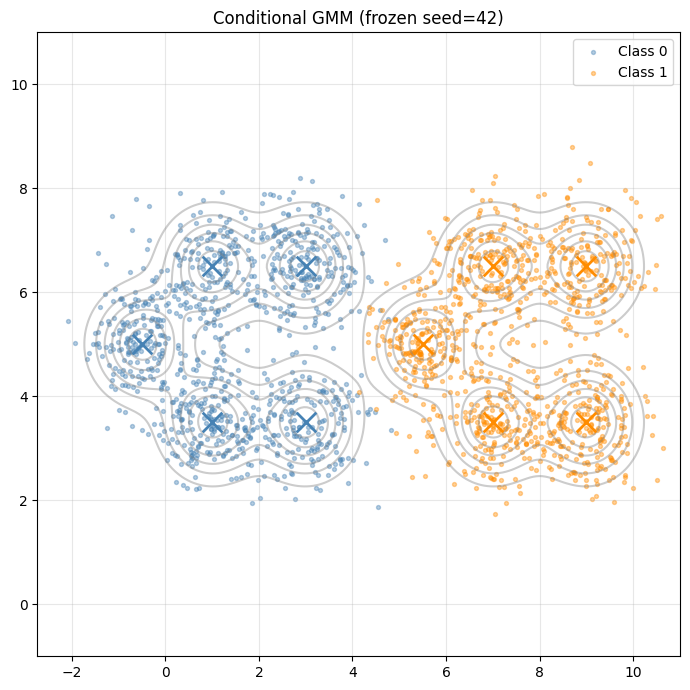

In [2]:
gmm = make_conditional_gmm(device=DEVICE, shape = "horseshoe")

x_vis, y_vis = gmm.sample(2000)
x_vis_np = x_vis.cpu().numpy()
y_vis_np = y_vis.cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 7))
gmm.contour_plot(colors='gray', alpha=0.4, xlim=(-2, 11))
for c, color, label in [(0, 'steelblue', 'Class 0'), (1, 'darkorange', 'Class 1')]:
    mask = y_vis_np == c
    ax.scatter(x_vis_np[mask, 0], x_vis_np[mask, 1], s=8, alpha=0.4,
               color=color, label=label)
modes = gmm.mode_centres().cpu().numpy()
ax.scatter(modes[:5, 0], modes[:5, 1], s=200, marker='x',
           color='steelblue', linewidths=2, zorder=5)
ax.scatter(modes[5:, 0], modes[5:, 1], s=200, marker='x',
           color='darkorange', linewidths=2, zorder=5)
ax.legend()
ax.set_title('Conditional GMM (frozen seed=42)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Train or load the denoising model

In [3]:
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
from diffusion.model import MLP

T = 1000
noise_scheduler = NoiseScheduler(num_timesteps=T).to(DEVICE)
MODEL_PATH = OUTPUTS_DIR / 'conditional_gmm_model.pt'

if MODEL_PATH.exists():
    model = load_model(MODEL_PATH, device=DEVICE)
    print('Loaded existing model.')
else:
    data, _ = gmm.sample(50_000)
    loader = DataLoader(TensorDataset(data.float()), shuffle=True, batch_size=256)
    model = MLP(hidden_size=128, hidden_layers=3, emb_size=128,
                time_emb='sinusoidal', input_emb='identity').to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    for epoch in tqdm(range(200)):
        model.train()
        for (x0,) in loader:
            x0 = x0.to(DEVICE)
            t = torch.randint(0, T, (x0.shape[0],), device=DEVICE).long()
            noise = torch.randn_like(x0)
            noisy = noise_scheduler.add_noise(x0, noise, t)
            loss = F.mse_loss(model(noisy, t), noise)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
    save_checkpoint(model, MODEL_PATH)
    model.eval()
    print('Trained and saved.')

Loaded existing model.


/Users/keesvanhemmen/PycharmProjects/SalienceSensitiveDiffusion/notebooks/../experiments/checkpoints.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(m

## 3. Train or load the noisy classifier

In [4]:
CLASSIFIER_PATH = OUTPUTS_DIR / 'conditional_gmm_classifier.pt'

if CLASSIFIER_PATH.exists():
    classifier = NoisyClassifier().to(DEVICE)
    classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=DEVICE))
    classifier.eval()
    print('Loaded existing classifier.')
else:
    classifier = train_noisy_classifier(
        gmm=gmm, scheduler=noise_scheduler, device=DEVICE,
        n_train=100_000, epochs=50, save_path=CLASSIFIER_PATH,
    )

Loaded existing classifier.


/var/folders/xz/wg0zp9292q9gsxt4ycvsm_640000gn/T/ipykernel_32512/1801551834.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load(CLASSIF

## 4. Verify classifier on clean data

In [5]:
x_test, y_test = gmm.sample(2000)
t_zero = torch.zeros(2000, device=DEVICE, dtype=torch.long)
with torch.no_grad():
    logits = classifier(x_test, t_zero)
acc = (logits.argmax(dim=-1) == y_test).float().mean().item()
print(f'Clean accuracy (t=0): {acc:.3f}')

Clean accuracy (t=0): 0.997


## 5. Setup

In [7]:
torch.manual_seed(0)
x_init = torch.randn(256, 2, device=DEVICE)
x_init_cls0 = x_init[:128]
x_init_cls1 = x_init[128:]

phi_align = ScoreAlignmentPhi()
sampler = SalientSampler(
    model=model, scheduler=noise_scheduler,
    phi=phi_align, device=DEVICE, guidance_frequency=1,
)

## 6. Run all four samplers

In [8]:
# 1. DDPM baseline
print('1/4 DDPM baseline...')
@torch.no_grad()
def sample_ddpm(x_init):
    x = x_init.clone()
    for t in reversed(range(T)):
        x = reverse_step(model, noise_scheduler, x, t)
    return x

x0_base_cls0 = sample_ddpm(x_init_cls0)
x0_base_cls1 = sample_ddpm(x_init_cls1)
print('Done.')

1/4 DDPM baseline...
Done.


In [9]:
# 2. Classifier guidance only
print('2/4 Classifier guidance...')
x0_cls_cls0 = sample_classifier_guided(
    model=model, classifier=classifier, scheduler=noise_scheduler,
    x_init=x_init_cls0, target_class=0, guidance_scale=1.0, verbose=True,
)
x0_cls_cls1 = sample_classifier_guided(
    model=model, classifier=classifier, scheduler=noise_scheduler,
    x_init=x_init_cls1, target_class=1, guidance_scale=1.0, verbose=True,
)
print('Done.')

2/4 Classifier guidance...
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
Done.


In [11]:
# 3. Score alignment guidance
print('3/4 Score alignment guidance...')
context = {"model": model, "scheduler": noise_scheduler}

x0_div_cls0 = sampler.sample_particle_grad_guided(
    x_init_cls0, guidance_scale=1.0, context=context, verbose=True,
)
x0_div_cls1 = sampler.sample_particle_grad_guided(
    x_init_cls1, guidance_scale=1.0, context=context, verbose=True,
)
print('Done.')

3/4 Score alignment guidance...
  t = 999
  t = 998
  t = 997
  t = 996
  t = 995
  t = 994
  t = 993
  t = 992
  t = 991
  t = 990
  t = 989
  t = 988
  t = 987
  t = 986
  t = 985
  t = 984
  t = 983
  t = 982
  t = 981
  t = 980
  t = 979
  t = 978
  t = 977
  t = 976
  t = 975
  t = 974
  t = 973
  t = 972
  t = 971
  t = 970
  t = 969
  t = 968
  t = 967
  t = 966
  t = 965
  t = 964
  t = 963
  t = 962
  t = 961
  t = 960
  t = 959
  t = 958
  t = 957
  t = 956
  t = 955
  t = 954
  t = 953
  t = 952
  t = 951
  t = 950
  t = 949
  t = 948
  t = 947
  t = 946
  t = 945
  t = 944
  t = 943
  t = 942
  t = 941
  t = 940
  t = 939
  t = 938
  t = 937
  t = 936
  t = 935
  t = 934
  t = 933
  t = 932
  t = 931
  t = 930
  t = 929
  t = 928
  t = 927
  t = 926
  t = 925
  t = 924
  t = 923
  t = 922
  t = 921
  t = 920
  t = 919
  t = 918
  t = 917
  t = 916
  t = 915
  t = 914
  t = 913
  t = 912
  t = 911
  t = 910
  t = 909
  t = 908
  t = 907
  t = 906
  t = 905
  t = 904
  t = 90

In [13]:
# 4. Combined
print('4/4 Combined guidance...')
context = {"model": model, "scheduler": noise_scheduler}

x0_combined_cls0 = sampler.sample_particle_grad_classifier(
    x_init_cls0, classifier=classifier, target_class=0,
    diversity_scale=1.0, classifier_scale=1.0,
    context=context, verbose=True,
)
x0_combined_cls1 = sampler.sample_particle_grad_classifier(
    x_init_cls1, classifier=classifier, target_class=1,
    diversity_scale=1.0, classifier_scale=1.0,
    context=context, verbose=True,
)
print('Done.')

4/4 Combined guidance...
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
Done.


## 7. Save samples

In [14]:
save_samples(torch.cat([x0_base_cls0,     x0_base_cls1]),
             'conditional_ddpm_baseline_simscore_exp',      SAMPLES_DIR)
save_samples(torch.cat([x0_cls_cls0,      x0_cls_cls1]),
             'conditional_classifier_guided_simscore_exp',  SAMPLES_DIR)
save_samples(torch.cat([x0_div_cls0,      x0_div_cls1]),
             'conditional_diversity_only_simscore_exp',     SAMPLES_DIR)
save_samples(torch.cat([x0_combined_cls0, x0_combined_cls1]),
             'conditional_combined_guidance_simscore_exp',  SAMPLES_DIR)

Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_ddpm_baseline_simscore_exp.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_ddpm_baseline_simscore_exp.npy
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_classifier_guided_simscore_exp.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_classifier_guided_simscore_exp.npy
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_diversity_only_simscore_exp.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_diversity_only_simscore_exp.npy
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_combined_guidance_simscore_exp.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/conditional_combined_guidance_simscore_exp.npy


## 8. Comparison figure

Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance/conditional_comparison_all_samplers_SimScorePhi.png


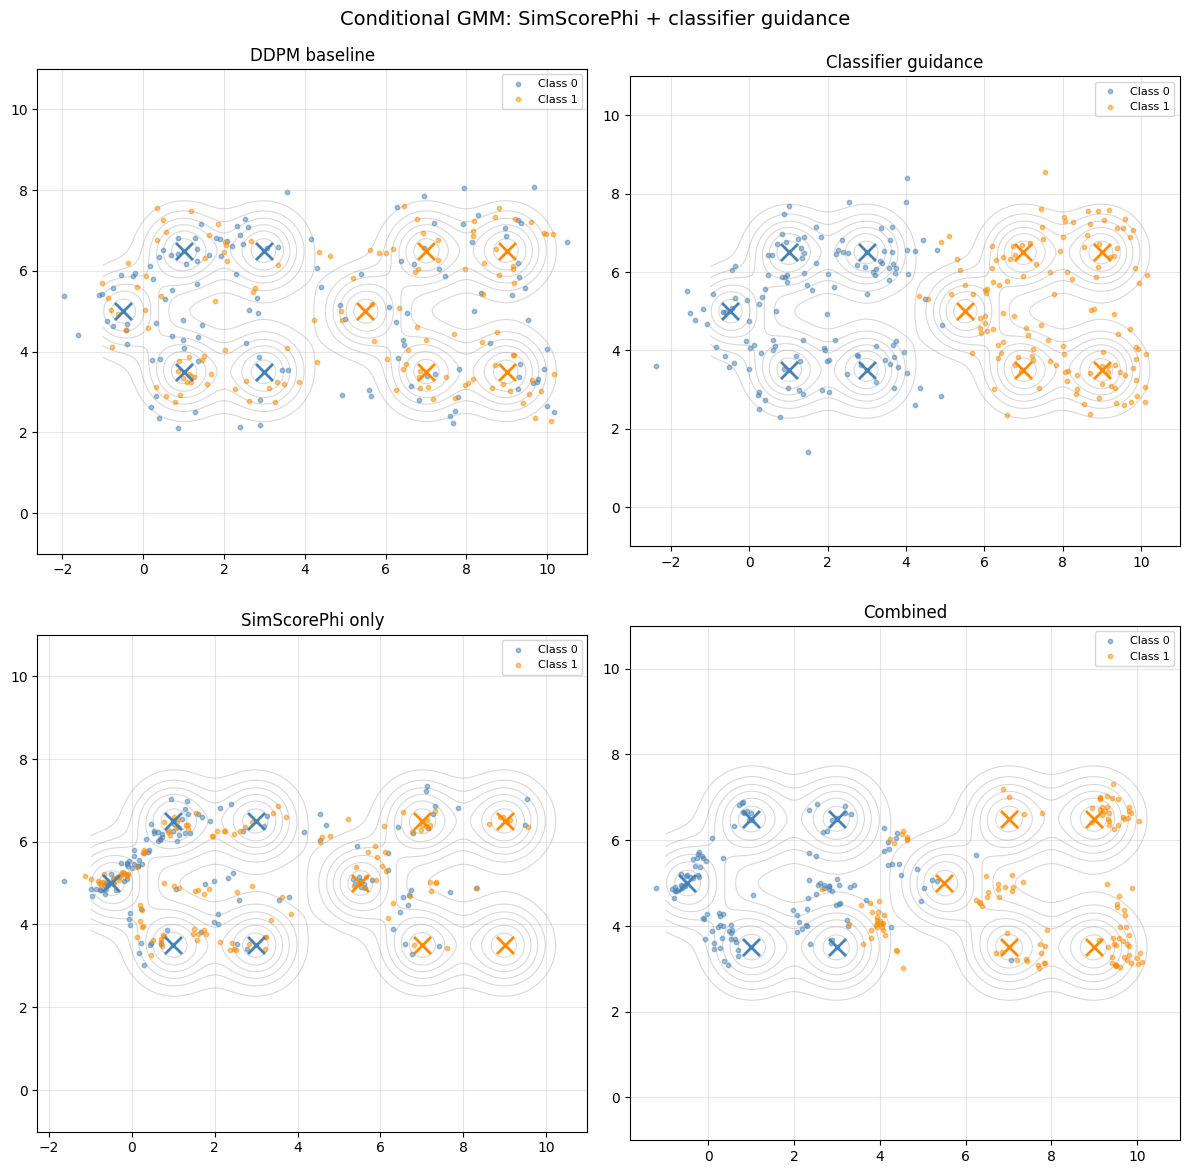

In [15]:
def plot_conditional_comparison(sample_pairs, gmm, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    modes = gmm.mode_centres().cpu().numpy()

    for ax, (title, c0, c1) in zip(axes, sample_pairs):
        plt.sca(ax)
        gmm.contour_plot(colors='gray', alpha=0.3, linewidths=0.8)
        c0_np = c0.detach().cpu().numpy()
        c1_np = c1.detach().cpu().numpy()
        ax.scatter(c0_np[:,0], c0_np[:,1], s=10, alpha=0.5,
                   color='steelblue', label='Class 0')
        ax.scatter(c1_np[:,0], c1_np[:,1], s=10, alpha=0.5,
                   color='darkorange', label='Class 1')
        ax.scatter(modes[:5,0], modes[:5,1], s=150, marker='x',
                   color='steelblue', linewidths=2, zorder=5)
        ax.scatter(modes[5:,0], modes[5:,1], s=150, marker='x',
                   color='darkorange', linewidths=2, zorder=5)
        ax.set_title(title, fontsize=12)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    return fig

fig = plot_conditional_comparison(
    sample_pairs=[
        ('DDPM baseline',       x0_base_cls0,     x0_base_cls1),
        ('Classifier guidance', x0_cls_cls0,      x0_cls_cls1),
        ('SimScorePhi only',      x0_div_cls0,      x0_div_cls1),
        ('Combined',            x0_combined_cls0, x0_combined_cls1),
    ],
    gmm=gmm,
    suptitle='Conditional GMM: SimScorePhi + classifier guidance',
)
save_figure(fig, 'conditional_comparison_all_samplers_SimScorePhi', PLOTS_DIR)
plt.show()

## 9. Classifier accuracy on generated samples

In [16]:
def classifier_accuracy(c0, c1, classifier, device):
    x = torch.cat([c0, c1]).to(device)
    y = torch.cat([
        torch.zeros(c0.shape[0], dtype=torch.long),
        torch.ones(c1.shape[0],  dtype=torch.long),
    ]).to(device)
    t = torch.zeros(x.shape[0], dtype=torch.long, device=device)
    with torch.no_grad():
        preds = classifier(x, t).argmax(dim=-1)
    return (preds == y).float().mean().item()

results = [
    ('DDPM baseline',       x0_base_cls0,     x0_base_cls1),
    ('Classifier guidance', x0_cls_cls0,      x0_cls_cls1),
    ('SimScorePhi only',      x0_div_cls0,      x0_div_cls1),
    ('Combined',            x0_combined_cls0, x0_combined_cls1),
]

print(f'{"Sampler":<25} {"Classifier accuracy":>20}')
print('-' * 47)
for name, c0, c1 in results:
    acc = classifier_accuracy(c0, c1, classifier, DEVICE)
    print(f'{name:<25} {acc:>20.3f}')

Sampler                    Classifier accuracy
-----------------------------------------------
DDPM baseline                            0.547
Classifier guidance                      0.984
SimScorePhi only                         0.520
Combined                                 0.836


## Ablation of guidance scales

In [24]:
# ---------------------------------------------------------------------------
# Ablation: combined guidance scale
# ---------------------------------------------------------------------------
from experiments.comparison import save_figure

ABLATION_SCALES = [0.1, 0.5, 1.0, 2.0, 3.0]

# Results stored as:
# ablation_cls[scale]  = (x0_cls0, x0_cls1)  -- classifier scale ablation
# ablation_div[scale]  = (x0_cls0, x0_cls1)  -- diversity scale ablation
ablation_cls = {}
ablation_div = {}

context = {"model": model, "scheduler": noise_scheduler}

# --- Classifier scale ablation (diversity fixed at 1.0) ---
print("Classifier scale ablation...")
for s in ABLATION_SCALES:
    print(f"  classifier_scale={s}")
    c0 = sampler.sample_particle_grad_classifier(
        x_init_cls0, classifier=classifier, target_class=0,
        diversity_scale=1.0, classifier_scale=s,
        context=context, verbose=False,
    )
    c1 = sampler.sample_particle_grad_classifier(
        x_init_cls1, classifier=classifier, target_class=1,
        diversity_scale=1.0, classifier_scale=s,
        context=context, verbose=False,
    )
    ablation_cls[s] = (c0, c1)
    save_samples(
        torch.cat([c0, c1]),
        name=f"ablation_cls_scale_{str(s).replace('.', 'p')}",
        root=SAMPLES_DIR,
    )

# --- SimScorePhi scale ablation (classifier fixed at 1.0) ---
print("SimScorePhi scale ablation...")
for s in ABLATION_SCALES:
    print(f"  simscorephi_scale={s}")
    c0 = sampler.sample_particle_grad_classifier(
        x_init_cls0, classifier=classifier, target_class=0,
        diversity_scale=s, classifier_scale=1.0,
        context=context, verbose=False,
    )
    c1 = sampler.sample_particle_grad_classifier(
        x_init_cls1, classifier=classifier, target_class=1,
        diversity_scale=s, classifier_scale=1.0,
        context=context, verbose=False,
    )
    ablation_div[s] = (c0, c1)
    save_samples(
        torch.cat([c0, c1]),
        name=f"ablation_div_scale_{str(s).replace('.', 'p')}",
        root=SAMPLES_DIR,
    )

Classifier scale ablation...
  classifier_scale=0.1
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_0p1.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_0p1.npy
  classifier_scale=0.5
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_0p5.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_0p5.npy
  classifier_scale=1.0
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_1p0.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_1p0.npy
  classifier_scale=2.0
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_2p0.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance/ablation_cls_scale_2p0.npy
  classifier_scale=3.0
Saved samples -> ../outputs/sampling_results/samples/classif

In [25]:
# ---------------------------------------------------------------------------
# Compute metrics for all ablation runs
# ---------------------------------------------------------------------------
from experiments.evaluation import distance_to_nearest_mode
import numpy as np

def compute_ablation_metrics(ablation_dict, classifier, device, gmm):
    """
    For each scale value, compute:
        - classifier accuracy on generated samples
        - mean pairwise diversity
        - mean distance to nearest mode
    Returns dict: {scale: {"accuracy": ..., "diversity": ..., "dist": ...}}
    """
    results = {}
    modes = gmm.mode_centres().cpu().numpy()

    for s, (c0, c1) in ablation_dict.items():
        # Classifier accuracy
        x_all = torch.cat([c0, c1]).to(device)
        y_all = torch.cat([
            torch.zeros(c0.shape[0], dtype=torch.long),
            torch.ones(c1.shape[0],  dtype=torch.long),
        ]).to(device)
        t_zero = torch.zeros(x_all.shape[0], dtype=torch.long, device=device)
        with torch.no_grad():
            preds = classifier(x_all, t_zero).argmax(dim=-1)
        acc = (preds == y_all).float().mean().item()

        # Mean pairwise diversity (per class, then averaged)
        c0_np = c0.detach().cpu().numpy()
        c1_np = c1.detach().cpu().numpy()

        def pairwise(x):
            diff = x[:, None, :] - x[None, :, :]
            dists = np.linalg.norm(diff, axis=-1)
            idx = np.triu_indices(len(x), k=1)
            return dists[idx].mean()

        div = (pairwise(c0_np) + pairwise(c1_np)) / 2.0

        # Mean distance to nearest mode
        dist = (
            distance_to_nearest_mode(c0_np, modes[:5]).mean() +
            distance_to_nearest_mode(c1_np, modes[5:]).mean()
        ) / 2.0

        results[s] = {"accuracy": acc, "ScoreSimPhi": div, "dist": dist}

    return results

metrics_cls = compute_ablation_metrics(ablation_cls, classifier, DEVICE, gmm)
metrics_div = compute_ablation_metrics(ablation_div, classifier, DEVICE, gmm)

# Print tables
for label, metrics in [("Classifier scale (div=1.0)", metrics_cls),
                        ("ScoreSimPhi scale (cls=1.0)",  metrics_div)]:
    print(f"\n{label}")
    print(f"{'Scale':<8} {'Accuracy':>10} {'ScoreSimPhi':>12} {'Dist to mode':>14}")
    print("-" * 46)
    for s in ABLATION_SCALES:
        m = metrics[s]
        print(f"{s:<8} {m['accuracy']:>10.3f} {m['ScoreSimPhi']:>12.3f} {m['dist']:>14.3f}")


Classifier scale (div=1.0)
Scale      Accuracy  ScoreSimPhi   Dist to mode
----------------------------------------------
0.1           0.504        3.730          2.299
0.5           0.832        3.119          1.069
1.0           0.883        2.884          0.969
2.0           0.988        2.375          0.736
3.0           0.992        2.459          0.804

ScoreSimPhi scale (cls=1.0)
Scale      Accuracy  ScoreSimPhi   Dist to mode
----------------------------------------------
0.1           0.984        2.671          0.733
0.5           0.957        2.426          0.782
1.0           0.898        2.703          0.986
2.0           0.586        3.482          1.928
3.0           0.633      951.731        477.861


Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance/ablation_classifier_scale_scatter_ScoreSimPhi.png


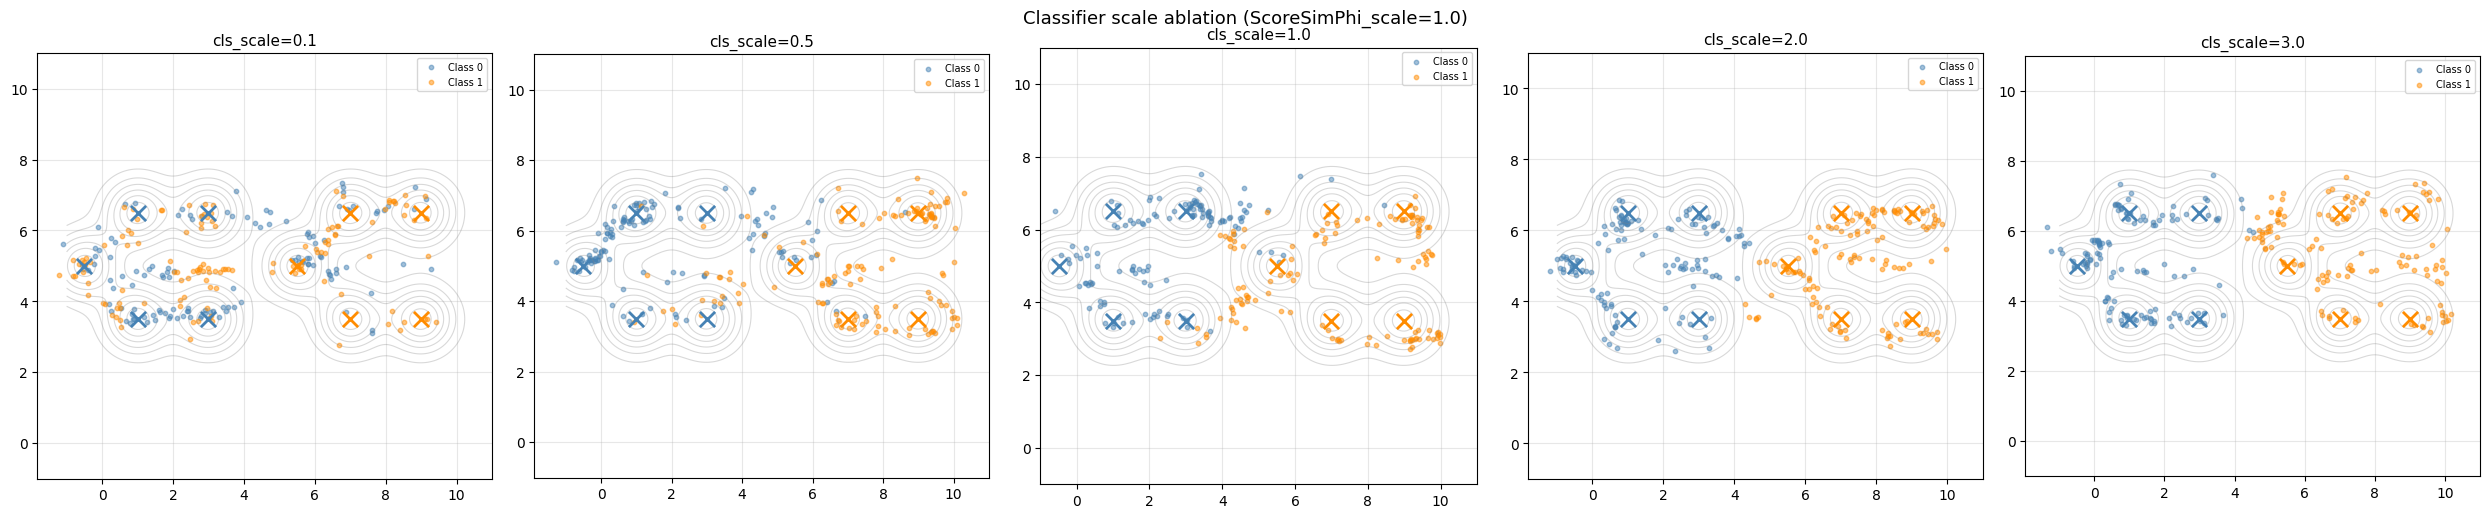

Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance/ablation_ScoreSimPhi_scale_scatter_ScoreSimPhi.png


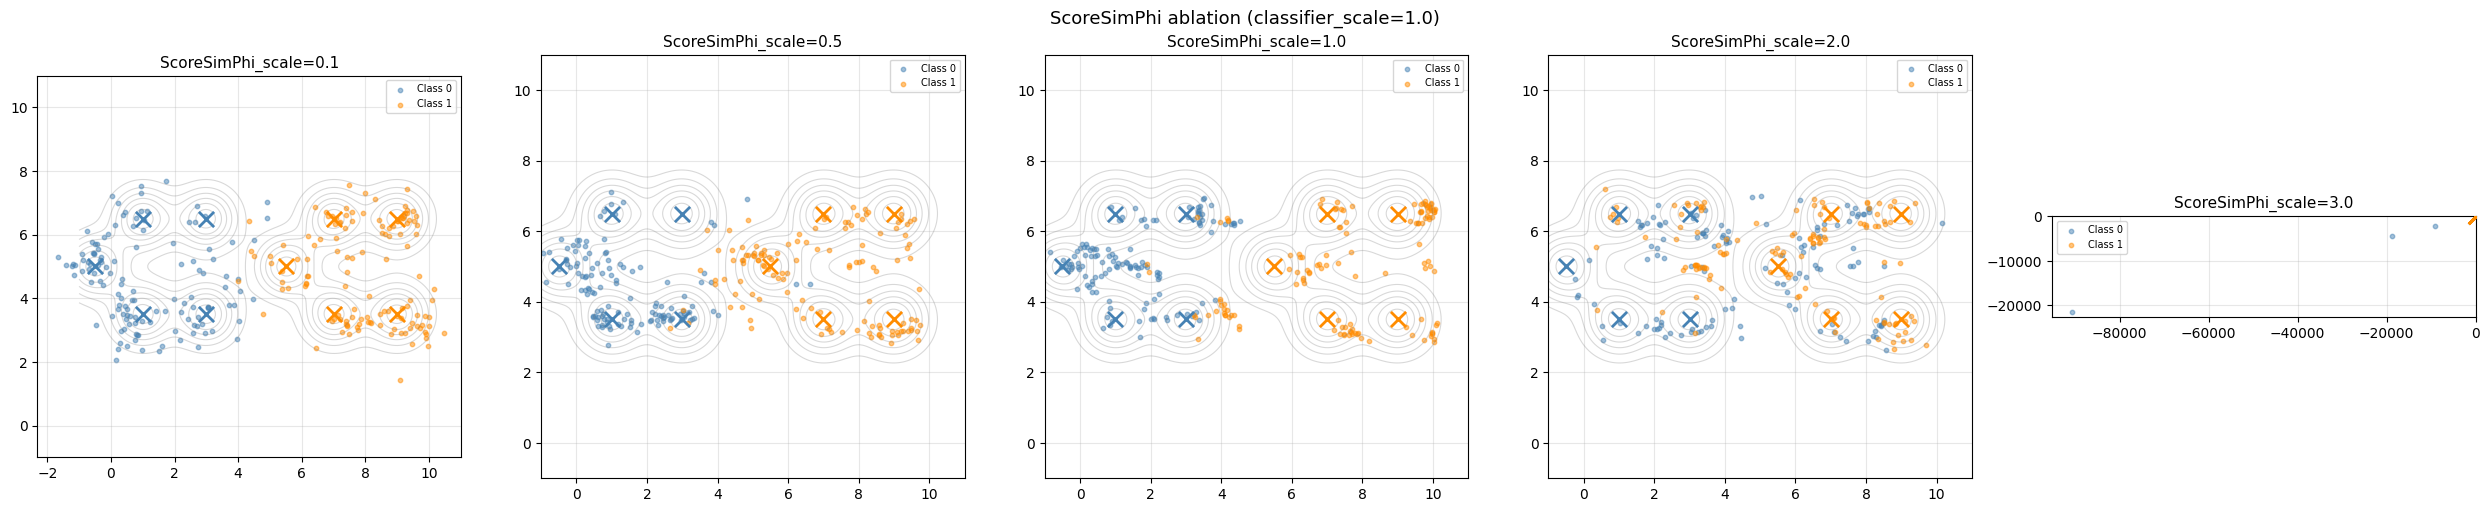

In [26]:
# ---------------------------------------------------------------------------
# Ablation scatter plots (5 panels per ablation)
# ---------------------------------------------------------------------------

def plot_ablation_scatter(ablation_dict, scales, gmm, title_prefix, suptitle):
    n = len(scales)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    modes = gmm.mode_centres().cpu().numpy()

    for ax, s in zip(axes, scales):
        c0, c1 = ablation_dict[s]
        plt.sca(ax)
        gmm.contour_plot(colors='gray', alpha=0.3, linewidths=0.8)
        ax.scatter(c0.cpu()[:,0], c0.cpu()[:,1], s=10, alpha=0.5,
                   color='steelblue', label='Class 0')
        ax.scatter(c1.cpu()[:,0], c1.cpu()[:,1], s=10, alpha=0.5,
                   color='darkorange', label='Class 1')
        ax.scatter(modes[:5,0], modes[:5,1], s=120, marker='x',
                   color='steelblue', linewidths=2, zorder=5)
        ax.scatter(modes[5:,0], modes[5:,1], s=120, marker='x',
                   color='darkorange', linewidths=2, zorder=5)
        ax.set_title(f"{title_prefix}={s}", fontsize=11)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    return fig


fig_cls_scatter = plot_ablation_scatter(
    ablation_cls, ABLATION_SCALES, gmm,
    title_prefix="cls_scale",
    suptitle="Classifier scale ablation (ScoreSimPhi_scale=1.0)",
)
save_figure(fig_cls_scatter, "ablation_classifier_scale_scatter_ScoreSimPhi", PLOTS_DIR)
plt.show()

fig_div_scatter = plot_ablation_scatter(
    ablation_div, ABLATION_SCALES, gmm,
    title_prefix="ScoreSimPhi_scale",
    suptitle="ScoreSimPhi ablation (classifier_scale=1.0)",
)
save_figure(fig_div_scatter, "ablation_ScoreSimPhi_scale_scatter_ScoreSimPhi", PLOTS_DIR)
plt.show()


Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance/ablation_metric_curves_ScoreSimPhi.png


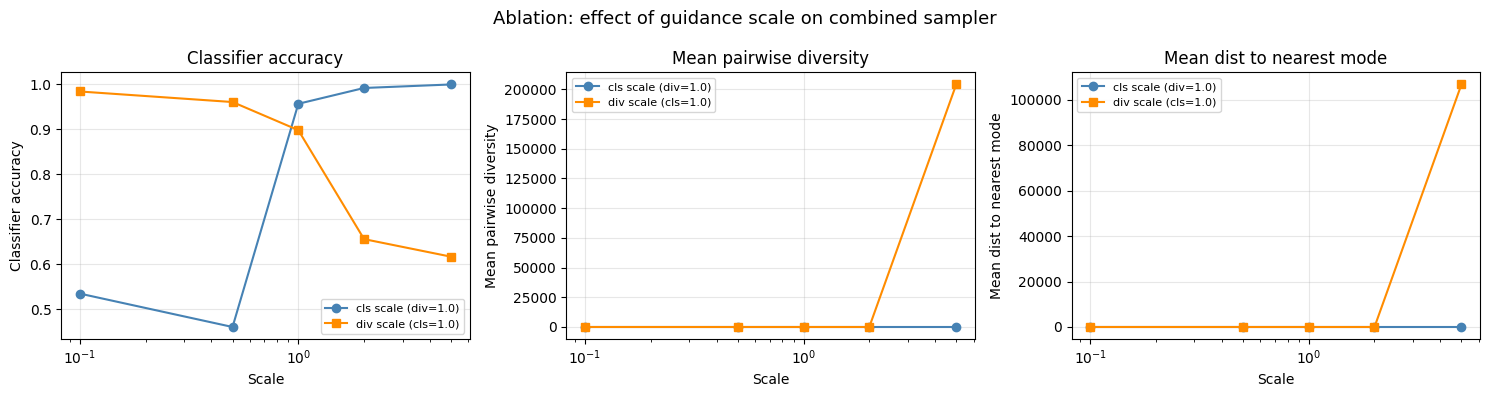

In [23]:
# ---------------------------------------------------------------------------
# Metric curves: accuracy and diversity vs scale
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_keys  = ["accuracy",   "ScoreSimPhi",       "dist"]
metric_labels = ["Classifier accuracy", "Mean pairwise diversity", "Mean dist to nearest mode"]

for ax, key, ylabel in zip(axes, metric_keys, metric_labels):
    vals_cls = [metrics_cls[s][key] for s in ABLATION_SCALES]
    vals_div = [metrics_div[s][key] for s in ABLATION_SCALES]

    ax.plot(ABLATION_SCALES, vals_cls, marker='o', label='cls scale (div=1.0)',
            color='steelblue')
    ax.plot(ABLATION_SCALES, vals_div, marker='s', label='div scale (cls=1.0)',
            color='darkorange')
    ax.set_xlabel("Scale")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Ablation: effect of guidance scale on combined sampler", fontsize=13)
plt.tight_layout()
save_figure(fig, "ablation_metric_curves_ScoreSimPhi", PLOTS_DIR)
plt.show()
